### Цель задачи

Проверить обратную связь между дебитом и давлением в упругом режиме:

- Сначала рассчитываем дебит $ q(t) $ при **постоянной депрессии** $ \Delta p = 6\,\text{МПа} $.
- Затем восстанавливаем давление $ p(t) $ из этого дебита с помощью **интеграла Дюамеля**.
- Если реализация верна, восстановленное давление должно быть близко к постоянному $ \Delta p $.

---

### Теоретическая основа

Давление и дебит связаны через **интеграл Дюамеля**:

$$
p(t) = \int_0^t q(\tau) \cdot p_1(t - \tau) \, d\tau,
$$

где:
- $ q(\tau) $ — дебит в момент $ \tau $,
- $ p_1(t) $ — функция влияния давления от **единичного импульса дебита** (δ-функции).

Если $ p_{\text{const}}(t) $ — давление при **постоянном дебите** $ q = 1 $, то:

$$
p_1(t) = \frac{d}{dt} p_{\text{const}}(t).
$$

---

### Реализация в коде

1. **Аналитические решения в пространстве Лапласа**:
   - Давление от единичного дебита:
     $$
     \tilde{p}(s) = \frac{\mu}{2\pi k h} \cdot \frac{K_0\!\left(r \sqrt{s/\eta}\right)}{s \, r_w \sqrt{s/\eta} \, K_1\!\left(r_w \sqrt{s/\eta}\right)}
     $$
   - Дебит от единичного давления ($ \Delta p = 1 $):
     $$
     \tilde{q}(s) = \frac{2\pi k h}{\mu B} \cdot \frac{1}{s} \cdot \frac{r_w \sqrt{s/\eta} \, K_1\!\left(r_w \sqrt{s/\eta}\right)}{K_0\!\left(r_w \sqrt{s/\eta}\right)}
     $$

2. **Обратное преобразование Лапласа** → временные функции `p_ls_d(t)` и `qd_unit(t)`.

3. **Масштабирование**:
   - Реальный дебит: $ q(t) = q_{\text{unit}}(t) \cdot \Delta p $,
   - Функция влияния: $ p_1(t) = \dfrac{d}{dt} p_{\text{const}}(t) $ (численно через `np.gradient`).

4. **Свёртка** (дискретный интеграл Дюамеля):
   $$
   p(t) \approx \sum_{\tau=0}^{t} q(\tau) \cdot p_1(t - \tau) \cdot \Delta t
   $$

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sc
import anaflow


dp = 6000000          # Па
B = 1.25                # м³/м³
k = 5e-15               # м²
h = 9.144               # м
phi = 0.3               # -
c_f = 1.47e-9           # 1/Па
c_r = 1e-9              # 1/Па
c_t = c_f + c_r         # 1/Па
rw = 0.1524             # м
r = rw                  # наблюдение в скважине
mu = 3e-3               # Па·с

eta = k / (mu * phi * c_t)

In [2]:
def pd_lapl_1(s, r=r, r_w=rw, k=k, h=h, mu=mu, eta=eta):
    u_r = r * np.sqrt(s / eta)
    u_rw = r_w * np.sqrt(s / eta)
    numerator = sc.kn(0, u_r)
    denominator = s * r_w * np.sqrt(s / eta) * sc.kn(1, u_rw)
    return mu * B / (2 * np.pi * k * h) * numerator / denominator

def q_lapl_unit(s, r_w=rw, B=B, k=k, h=h, mu=mu, eta=eta):
    u = r_w * np.sqrt(s / eta)
    return (2 * np.pi * k * h) / (mu * B) * (1 / s) * (u * sc.k1(u)) / sc.k0(u)

p_ls = anaflow.get_lap_inv(pd_lapl_1)
q_ls_unit = anaflow.get_lap_inv(q_lapl_unit)

In [3]:
x = np.linspace(1, 20000, 1500)
dt = x[1] - x[0]


qd_unit = q_ls_unit(x)
qd = qd_unit * dp


p_ls_d = p_ls(x)
p1_d = np.gradient(p_ls_d, dt)

In [4]:
pd_values = []
for t_idx in range(len(x)):
    p_t = 0.0
    for tau_idx in range(t_idx + 1):
        p_t += qd[tau_idx] * p1_d[t_idx - tau_idx] * dt
    pd_values.append(p_t)

pd_values = np.array(pd_values)

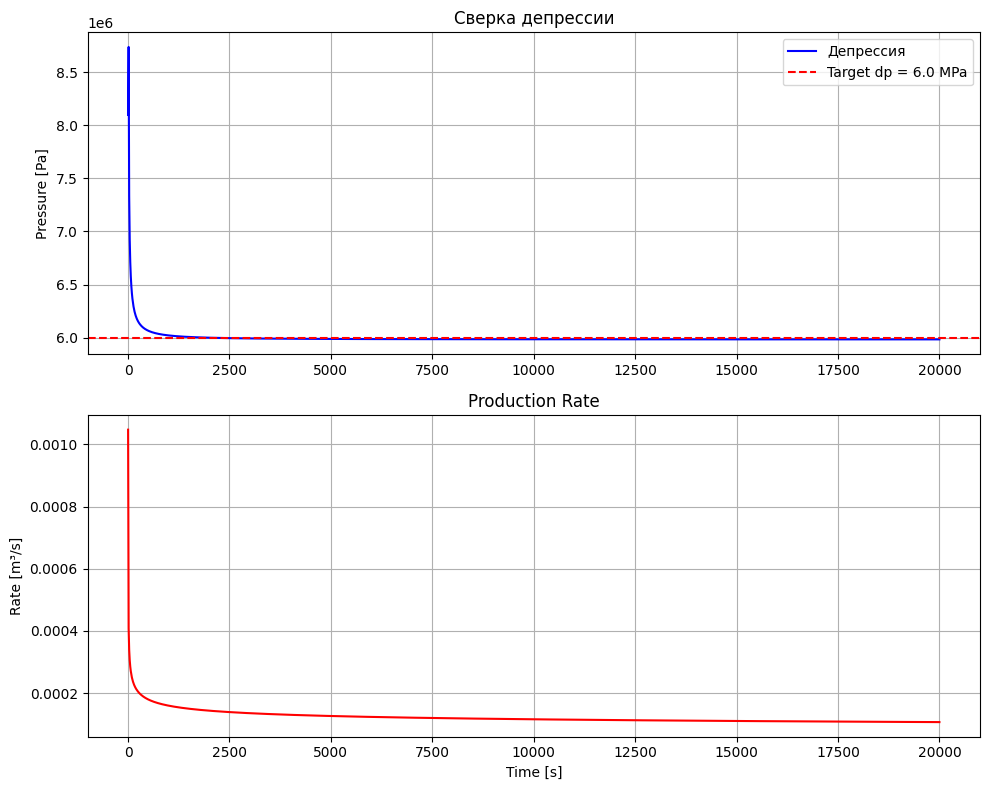

Initial rate: 1.047062e-03 m³/s
Initial p1 (impulse response): 5.796e+08 Pa/s per m³/s
Final recovered pressure: 5.984e+06 Pa
Relative error at end: -0.27 %


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(x, pd_values, label='Депрессия', color='blue')
ax1.axhline(y=dp, color='red', linestyle='--', label=f'Target dp = {dp/1e6:.1f} MPa')
ax1.set_ylabel('Pressure [Pa]')
ax1.set_title('Сверка депрессии')
ax1.legend()
ax1.grid(True)

ax2.plot(x, qd, label='Rate (qd)', color='red')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Rate [m³/s]')
ax2.set_title('Production Rate')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Initial rate: {qd[0]:.6e} m³/s")
print(f"Initial p1 (impulse response): {p1_d[0]:.3e} Pa/s per m³/s")
print(f"Final recovered pressure: {pd_values[-1]:.3e} Pa")
print(f"Relative error at end: {(pd_values[-1] - dp) / dp * 100:.2f} %")

In [6]:
pip install anaflow

Note: you may need to restart the kernel to use updated packages.
